# 05 - Pipeline Experiments

In questo notebook centralizziamo l'intera pipeline di sperimentazione.
A differenza del notebook precedente (`04_finetuning_baseline.ipynb`), qui abbiniamo **PyTorch Lightning** a **Weights & Biases (WandB)** e spostiamo gli iperparametri in `config.yaml`.

- **`src.lightning_modules.LitResNet`**: contiene la logica di addestramento e validazione.
- **`config.yaml`**: contiene gli iperparametri dell'esperimento gestiti via `OmegaConf`.
- **WandB**: registra curve di training e validation nel cloud per confrontare run diverse.

Rispetto alla baseline locale, manteniamo lo stesso backbone (`ResNet-18`) e lo stesso ottimizzatore (`AdamW`), ma aggiungiamo pesi di classe, augmentation piu' robusta, early stopping e tracking strutturato.


In [1]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

import torch
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb
from omegaconf import OmegaConf

from src.dataset import get_dataloaders, get_class_weights
from src.lightning_modules import LitResNet
from src.utils import set_seed

set_seed(42)

# Ottimizzazione per Tensor Cores (RTX serie 3000/4000)
torch.set_float32_matmul_precision('medium')

# Caricamento della configurazione da YAML
cfg = OmegaConf.load('config.yaml')
print(OmegaConf.to_yaml(cfg))

dataset:
  data_dir: ../_data
  batch_size: 512
  num_workers: 8
  augmentation: heavy_blur
model:
  name: resnet18
  num_classes: 43
  pretrained: true
training:
  epochs: 50
  lr: 0.0001
  optimizer: adamw
  label_smoothing: 0.1
  use_onecycle_lr: true
  use_class_weights: true
  early_stopping_patience: 5
logging:
  project_name: DeepLearningApplicationLab1
  run_name: final



## 1. Caricamento Dataset

Carichiamo i DataLoader usando batch size, directory dati e strategia di augmentation definiti in `config.yaml`.

In [2]:
train_dl, val_dl, test_dl = get_dataloaders(
    data_dir=cfg.dataset.data_dir,
    batch_size=cfg.dataset.batch_size,
    num_workers=cfg.dataset.num_workers,
    augmentation_strategy=cfg.dataset.augmentation
)

## 2. Inizializzazione Modello e Addestramento (Tracking su WandB)

Colleghiamo il `WandbLogger` al Trainer di PyTorch Lightning. Le metriche calcolate dentro `LitResNet` (`val/loss`, `val/accuracy`, `val/f1_score`, ecc.) vengono trasmesse automaticamente a WandB.

In questa versione consolidata introduciamo due scelte motivate dall'EDA: i pesi di classe nella loss, per compensare lo sbilanciamento, e la strategia di augmentation `heavy_blur`, per rendere il modello piu' robusto a rotazioni leggere, variazioni cromatiche e sfocatura.


In [3]:
from pytorch_lightning.callbacks import TQDMProgressBar, ModelCheckpoint

from pytorch_lightning.callbacks.early_stopping import EarlyStopping

# Otteniamo i pesi delle classi per bilanciare la loss
class_weights = (
    get_class_weights(cfg.dataset.data_dir)
    if cfg.training.use_class_weights
    else None
)


# Inizializziamo il modulo passando esplicitamente i parametri (massima modularità)
lit_model = LitResNet(
    model_name=cfg.model.name,
    num_classes=cfg.model.num_classes, 
    pretrained=cfg.model.pretrained,
    lr=cfg.training.lr,
    class_weights=class_weights,
    optimizer_name=cfg.training.optimizer,
    label_smoothing=cfg.training.label_smoothing,
    use_onecycle_lr=cfg.training.use_onecycle_lr,
)

# Inizializziamo il Logger di WandB. log_model=True carica automaticamente su WandB
# il checkpoint migliore salvato da ModelCheckpoint, come backup versionato in cloud.
wandb_logger = WandbLogger(
    project=cfg.logging.project_name, 
    name=cfg.logging.run_name,
    config=OmegaConf.to_container(cfg, resolve=True),
    log_model=True,
)

# Logger CSV locale in parallelo a WandB: le curve restano disponibili anche offline,
# senza dipendere da credenziali cloud per confrontare le run (vedi sezione finale).
# Usiamo una nuova versione per confrontare la pipeline con la baseline corretta senza alterare i log storici.
csv_logger = CSVLogger(save_dir="logs", name="pipeline_final", version=1)

# Inizializziamo il Trainer associando il logger e la barra avanzata
# Configurazione Early Stopping
early_stop_callback = EarlyStopping(
    monitor="val/loss",
    min_delta=0.00,
    patience=cfg.training.early_stopping_patience,
    verbose=False,
    mode="min"
)

# Salviamo il checkpoint con il miglior F1-score macro di validazione.
checkpoint_callback = ModelCheckpoint(
    monitor="val_f1_score",
    mode="max",
    dirpath="checkpoints/pipeline_final",
    filename="resnet18-pipeline-{epoch:02d}-{val_f1_score:.3f}",
    save_top_k=1,
)

# Forziamo TQDM per risolvere i conflitti visivi di Rich in VS Code
progress_bar = TQDMProgressBar(refresh_rate=10)

trainer = pl.Trainer(
    max_epochs=cfg.training.epochs,
    accelerator="auto",
    logger=[wandb_logger, csv_logger],
    callbacks=[early_stop_callback, checkpoint_callback, progress_bar],
    log_every_n_steps=10
)

# Avvio della sperimentazione.
print('Avvio esperimento monitorato su WandB...')
trainer.fit(lit_model, train_dataloaders=train_dl, val_dataloaders=val_dl)

# Valutiamo il checkpoint con F1 macro migliore, non lo stato dell'ultima epoca.
print('\nInizio calcolo metriche di Validation finali...')
trainer.validate(dataloaders=val_dl, ckpt_path="best")

# Esecuzione finale sul test set puro.
print('\nInizio test finale...')
trainer.test(dataloaders=test_dl, ckpt_path="best")

wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\franc\.netrc.


Avvio esperimento monitorato su WandB...


wandb: Currently logged in as: francescoberaldi01 (francescoberaldi01-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_f1   │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

...

Restoring states from the checkpoint path at C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB1\exercise_2_gtsrb_classification\checkpoints\pipeline_final\resnet18-pipeline-epoch=35-val_f1_score=1.000.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB1\exercise_2_gtsrb_classification\checkpoints\pipeline_final\resnet18-pipeline-epoch=35-val_f1_score=1.000.ckpt



Inizio test finale...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/accuracy       │     0.985589861869812     │
│       test/f1_score       │    0.9777528643608093     │
│         test/loss         │    1.1475425958633423     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇████
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▄▇▇████████████████████████████████████
train/f1_score,▁▄▇█████████████████████████████████████
train/loss_epoch,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss_step,█▄▄▂▂▂▂▂▂▁▂▁▂▂▂▂▁▁▂▂▁▂▂▁▂▁▁▁▁▂▁▂▁▂▂▁▂▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
val/accuracy,▁▅▇█████████████████████████████████████
+3,...


## 3. Confronto con la baseline (Esercizio 3.1)

L'Esercizio 3.1 chiede di iterare sul fine-tuning per migliorarne le prestazioni. Le scelte introdotte in questa pipeline rispetto alla baseline locale (`04_finetuning_baseline.ipynb`) — pesi di classe, augmentation `heavy_blur`, label smoothing, `OneCycleLR`, early stopping — vengono qui confrontate quantitativamente, leggendo le curve locali salvate da entrambi i notebook tramite `CSVLogger` (nessuna dipendenza da WandB per questo confronto, cosi' resta riproducibile offline).

Con i checkpoint migliori, la baseline ottiene test accuracy `0.9347` e F1 macro `0.8906`, mentre la pipeline raggiunge `0.9856` e `0.9778`. Il guadagno e' quindi `+0.0509` in accuracy e `+0.0872` in F1 macro.

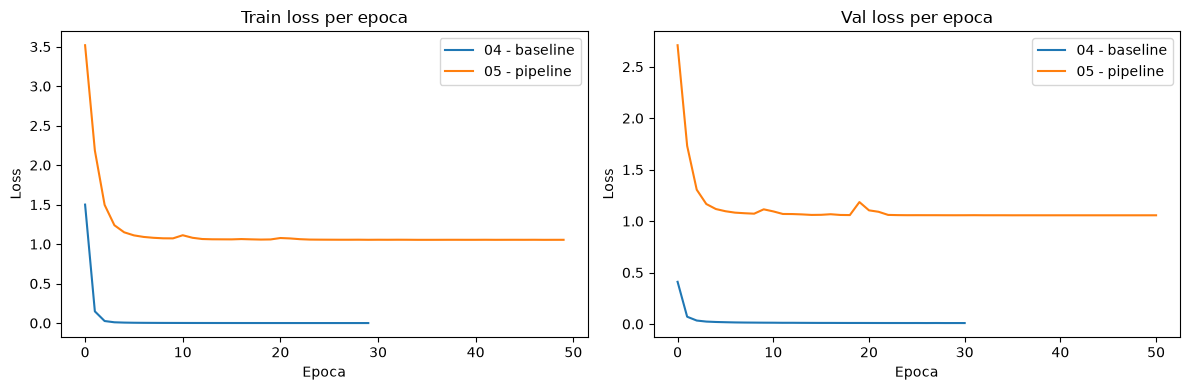

In [4]:
from src.utils import load_epoch_metrics, load_final_test_metrics
import matplotlib.pyplot as plt

baseline_metrics = load_epoch_metrics("logs/finetuning_baseline/version_1/metrics.csv")
pipeline_metrics = load_epoch_metrics("logs/pipeline_final/version_1/metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_metrics.index, baseline_metrics["train/loss_epoch"], label="04 - baseline")
axes[0].plot(pipeline_metrics.index, pipeline_metrics["train/loss_epoch"], label="05 - pipeline")
axes[0].set_title("Train loss per epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(baseline_metrics.index, baseline_metrics["val/loss"], label="04 - baseline")
axes[1].plot(pipeline_metrics.index, pipeline_metrics["val/loss"], label="05 - pipeline")
axes[1].set_title("Val loss per epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

baseline_test = load_final_test_metrics("logs/finetuning_baseline/version_1/metrics.csv")
pipeline_test = load_final_test_metrics("logs/pipeline_final/version_1/metrics.csv")

comparison_table = pd.DataFrame({
    "04 - baseline": baseline_test,
    "05 - pipeline": pipeline_test,
})
comparison_table["delta"] = comparison_table["05 - pipeline"] - comparison_table["04 - baseline"]
comparison_table

,04 - baseline,05 - pipeline,delta
test/accuracy,0.934679,0.985590,0.050911
test/f1_score,0.890564,0.977753,0.087189


**Nota sulla scala delle loss**: le curve di `05` si stabilizzano intorno a 1,05, mentre quelle di `04` scendono vicino a zero. Non e' un peggioramento: `05` usa `label_smoothing=0.1` e pesi di classe nella cross-entropy, che mantengono la loss numericamente piu' alta rispetto alla cross-entropy non regolarizzata di `04`. Le curve non sono confrontabili in valore assoluto; il confronto va fatto sulle metriche finali (accuracy/F1) riportate nella tabella.

## 4. Configurazione Finale

Il checkpoint migliore su F1 macro di validation e' quello dell'epoca 35. Sul test
set la pipeline ottiene accuracy `0.9856` e F1 macro `0.9778`, rispetto a `0.9347`
e `0.8906` della baseline. I valori sono riportati anche nella tabella prodotta dalla
cella precedente e nei log CSV locali della run `version_1`.

**Dettagli della Configurazione:**
- **Ecosistema**: PyTorch Lightning con tracciamento metriche su Weights & Biases (WandB).
- **Architettura**: `ResNet-18` (pre-addestrata su ImageNet, *full fine-tuning* per 43 classi).
- **Ottimizzatore**: configurato da `config.yaml` tramite `cfg.training.optimizer`; nella configurazione corrente e' `adamw` con learning rate di base `1e-4`.
- **Scheduler**: `OneCycleLR` (`max_lr` pari a 10 volte il learning rate di base, aggiornamento step-by-step a ogni batch).
- **Loss**: `CrossEntropy` con `label_smoothing=0.1` e pesi di classe calcolati sul training set, per ridurre l'impatto dello sbilanciamento tra classi.
- **Data Augmentation (Heavy Blur)**:
  - `Resize(68)` e `RandomCrop(64)`
  - `RandomRotation(15)`
  - `ColorJitter` (luminosita', contrasto, saturazione)
  - `GaussianBlur(kernel_size=3)` con probabilita' del 20%
- **Training Setup**: 50 epoche massime, batch size 512, progress bar `TQDMProgressBar`, precisione Tensor Cores ottimizzata su GPU, checkpoint del miglior F1 macro di validazione.

Questa configurazione mantiene coerenti le scelte di base del notebook 04, ma aggiunge gli elementi richiesti da una pipeline sperimentale riproducibile: configurazione esterna, logging cloud, gestione dello sbilanciamento e augmentation piu' aderente alle osservazioni dell'EDA.